# (리뷰) NAS, Zoph2016

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [강화학습]


### About this doc 

`-` 강화학습의 응용분야중 하나인 AutoML을 다루는 논문리뷰
- Zoph, B., & Le, Q. V. (2016). Neural architecture search with reinforcement learning. arXiv preprint arXiv:1611.01578.


### 지나친 의인화에 대한 불편함  

`-` 인공지능을 이해할때 가장 경계해야할 부분이 **"지나친 의인화"** 라고 생각한다. 컴퓨터는 **학습**을 하는게 아니라 **계산**을 하는 것이다. **훈련**과 **예측**을 하는게 아니고 **계산**과 **계산**을 하는 것이다. 물론 의인화가 직관적인 이해에는 도움이 되지만 지나친 의인화는 학술적이지 않다는 생각이 든다. 

`-` 이런 점에서 이 논문은 제시하는 기술력에 비해서 의인화가 너무 거창하다는 느낌을 지울 수 없다. 무려 **인공지능을 만드는 인공지능이다** 라는 슬로건으로 나온 논문이라 정말 엄청나게 혁신적인 알고리즘을 제시한 줄 알았는데 그렇지 않았다. 상당히 비효율적으로 보였다 심지어 몇몇 부분에서는 저자들이 다른분야를 제대로 이해하고 쓴건 맞는가? 라는 의문도 들었다. (1) 먼저 RNN 방식을 왜 사용해야 하는지에 대한 이유가 석연치 않다. 저자들이 설명을 하지 않아 그 motivation 을 이해하는것이 쉽지 않다. 적어도 내가 이해하는 한도내에서는 RNN을 쓸 필요가 없다. (2) 저자들이 제시한 방법은 결국 강화학습을 활용하여 아키텍처를 설계하는 하이퍼파라미터를 옵티마이징 하는것인데 다른방법에 비하여 얼마나 효율적으로 옵티마이징 하는지 비교하지 않았다. 애초에 굳이 강화학습을 이용해야 했는지 자체도 의문이다. 



### Toy Example 

`-` 논문을 이해하기 쉬운 장난감예제를 구성. 

`-` 나스가 RNN을 사용하므로, RNN아키텍처에 대한 선행지식이 필요함. 



### 예제소개 

`-` 이해를 돕기 위해서 가벼운 예제를 도입하였다. 개인적으로 이 논문의 방법이 문제가 많다고 생각하지만 우선 이 예제를 설명하는 범위내에서는 이러한 문제점을 언급하지 않겠다. 이 챕터에서는 단지 저자들이 주장하는 NAS가 어떻게 동작하는지 그리고 어떻게 구현할 수 있는지 이해하는데에만 초점을 맞추겠다. 중간중간에 "아니 이걸 이렇게 (비효율적으로) 구한다고?" 싶은것도 많고 저자들의 생각에 비판의 여지도 많겠겠만 (틀린거 같아) 이것은 다음챕터에서 몰아서 논의하고 이번에는 그냥 이해에만 초점을 맞추도록 하자. 

`-` 아래와 같은 데이터셋 $(x_i,y_i)$ 이 있다고 가정하자. 

$$y_i=2 x_ i + \epsilon_i$$

여기에서 $\epsilon_i$ 는 에러텀이다. 

In [4]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

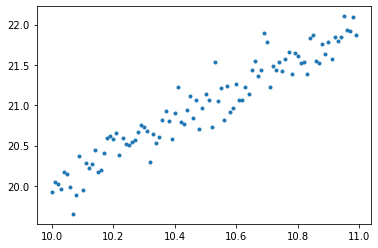

In [5]:
x=np.array(range(1000,1100))/100
y=2*x+0.2*np.random.randn(100)
plt.plot(x,y,'.')



`-` 위와 같은 자료에서 우리가 학습하고 싶은 것은 

$$\sum_{i=1}^{n}\big(y_i-f(x_i)\big)^2$$

을 최소화 하는 어떠한 함수 $f(x)$ 이다. 그리고 당연히 이때 $f(x)=2x$ 이다. 

`-` $f(x)$를 학습하기 위해서 each observation $i$에 대하여 아래와 같은 구조를 가지는 MLP 를 쌓았다고 가정하자. 

$$y_i = g\big(h(x_i u) v\big) $$

여기에서 $u$, $v$는 weight 이고 $g$ 와 $h$ 는 activation function 이다. $g\big(h(x_i u) v\big)=2x $ 가 되는것이 최적이므로 $g$ 와 $h$ 를 모두 linear activation 으로 설정하고 $uv=2 $ 가 되도록 하는 weight 를 설정하면 된다. 이게 최선이다. 

### NAS의 셋팅: 아키텍처의 선택문제를 

`-` 이 상황에서 우리는 activation 의 선택지를 sigmoid 와 linear 로 주고 적절한 activation 을 선택하게끔 만드는 NAS를 구성할 것이다. 즉 우리의 예제에서 NAS가 선택해야 하는 조합의 수는 아래의 4가지이다. 

**(1)** $h(x)=x$, $g(x)=x$ 

**(2)** $h(x)=x$, $g(x)=\frac{e^x}{1+e^x}$ 

**(3)** $h(x)=\frac{e^x}{1+e^x}$, $g(x)=x$ 

**(4)** $h(x)=\frac{e^x}{1+e^x}$, $g(x)=\frac{e^x}{1+e^x}$ 

참고로 최선의 선택은 당연히 **(1)** 이다. 

`-` NAS는 여기에서 2개의 action 을 취하게 된다. 하나는 $h$를 고르는 action 이고 하나는 $g$를 고르는 action 이다. 편의상 이 action을 각각 $A_1$ 과 $A_2$ 라고 하자. $A_1$, $A_2$ 가 대문자인 이유는 확률변수이기 때문이다. 그리고 $A_1, A_2$의 실현값을 각각 $a_1,a_2$ 라고 하자. 선택할 수 있는 action 은 linear activation 을 고르거나 sigmoid activation 을 고르거나 둘 중하나 이므로 ${\cal A}=\{ linear,~ sigmoid \}$ 이다. 편의상 ${\cal A}=\{0,1\}$ 이라고 정의하자. 

`-` 이제 **에이전트(=컨트롤러)** 와 **엔바이러먼트(혹은 신)** 을 정의하자. 여기에서 **에이전트**는 적절한 $h$와 $g$를 고르는 주체이고 **신**은 에이전트의 선택이 적절한지 적절하지 않은지 보상을 주는 존재이다. 참고로 여기에서 에이전트가 $(h,g)$를 고른다는 말은 적절한 $(a_1,a_2)$를 고른다는 말과 같고 이말은 $f(x)$를 추론하기 위한 적절한 아키텍처를 고른다는 말과 같음을 상기하자. **신**이 주는 보상은 에이전트의 아키텍처에 대한 MSE값 즉 

$$\sum_{i=1}^{n} \big(y_i-\hat{f}(x)\big)^2$$

값이다. 에이전트가 고를 수 있는 아키텍처는 4개이므로 신이 줄수 있는 보상도 아래의 4개이다. 

**(1)** $r_{00}:=r\big(A_1=0,A_2=0\big):$ 에이전트가 (linear, linear)를 활성화함수로 선택했을때 보상. 

**(2)** $r_{01}:=r\big(A_1=0,A_2=1\big):$ 에이전트가 (linear, sigmoid)를 활성화함수로 선택했을때 보상.  

**(3)** $r_{10}:=r\big(A_1=1,A_2=0\big):$ 에이전트가 (sigmoid, linear)를 활성화함수로 선택했을때 보상.  

**(4)** $r_{11}:=r\big(A_1=1,A_2=1\big):$ 에이전트가 (sigmoid,sigmoid)를 활성화함수로 선택했을때 보상. 

따라서 ${\cal R}=\{r_{00},r_{01},r_{10},r_{11}\}$ 이다. 



`-` 보상함수가 랜덤이냐 아니냐에 에 대한 해석이 좀 헷갈린다. 하지만 통계학과가 아니라면 헷갈일이 없으니 별로 안헷갈린다면 이 부분에 대한 설명은 넘어가자. 

**(1) 강화학습의 관점**: 고정된 $(x_i,y_i)$에 대하여 MSE는 항상 하나의 값만 가지므로 이 경우 보상함수는 강화학습이 셋팅에서 흔히 말하는 **랜덤함수가 아니다.** 강화학습에서 보상이 랜덤이라는 의미는 **given $S_t$** 에서 동일한 행동 $A_t$를 취해도 받게되는 보상값이 $R_{t+1}$이 다를수 있다는 것이다. $4\times 4$ 그리드 세계를 비유하면 똑같은 위치에서 똑같은 방향으로 움직였는데 갑자기 바람이 획불어서 엉뚱한 상태로 가 벌점을 받게되는 상황으로 비유가능하다. 하지만 여기에서는 그렇지 않으므로 (action을 동일하게 하면 보상함수는 일정하다) 보상함수는 랜덤이 아니다. 그래서 엔바이러먼트가 줄 수 있는 보상은 딱 위의 4개의 경우밖에 없다.

**(2) 통계적 관점**: 일반적인 회귀분석적 셋팅하에서는 $\epsilon_i$이 랜덤이므로 SSE 역시 카이제곱분포를 따르는 랜덤이다. 

말이 좀 헷갈리긴 해도 잘 생각해보면 쉽게 이해할 수 있을 것이라 생각한다. 보통 딥러닝 셋팅에서는 에러텀 가정이 없으므로 given data 는 절대로 안변하는 어떠한 고정불변의 값처럼 생각하는 경우가 많다. 그래서 강화학습에서 랜덤이라는 말은 given data $x_i,y_i$가 모두 고정값일때에도 랜덤이라는 말이다. 하지만 통계학자들은 given data 자체가 어떠한 random variable 의 realization 으로 보기때문에 $y_i$ 자체를 랜덤으로 생각한다. 

#### 보상의 추정 

`-`이 예제에 한정하여 $r_{00},\dots,r_{11}$을 구해보자. 

In [7]:
#collapse_output
## r00
model1 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
model1.add(tf.keras.layers.Dense(1,activation='linear'))
model1.compile(loss='mean_squared_error', optimizer='adam')
model1.fit(x, y, epochs=2000)

Epoch 1/2000
4/4 [==============================] - 0s 1ms/step - loss: 303.9742
Epoch 2/2000
4/4 [==============================] - 0s 797us/step - loss: 302.0032
Epoch 3/2000
4/4 [==============================] - 0s 791us/step - loss: 300.0244
Epoch 4/2000
4/4 [==============================] - 0s 919us/step - loss: 298.0382
Epoch 5/2000
4/4 [==============================] - 0s 880us/step - loss: 296.0433
Epoch 6/2000
4/4 [==============================] - 0s 627us/step - loss: 294.0413
Epoch 7/2000
4/4 [==============================] - 0s 673us/step - loss: 292.0320
Epoch 8/2000
4/4 [==============================] - 0s 663us/step - loss: 290.0086
Epoch 9/2000
4/4 [==============================] - 0s 1ms/step - loss: 287.9873
Epoch 10/2000
4/4 [==============================] - 0s 626us/step - loss: 285.9546
Epoch 11/2000
4/4 [==============================] - 0s 684us/step - loss: 283.9127
Epoch 12/2000
4/4 [==============================] - 0s 721us/step - loss: 281.8679
Epoch

In [13]:
#collapse_output
## r01
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='linear'))
model2.add(tf.keras.layers.Dense(1,activation='sigmoid'))
model2.compile(loss='mean_squared_error', optimizer='adam')
model2.fit(x, y, epochs=2000)

Epoch 1/2000
4/4 [==============================] - 0s 489us/step - loss: 441.0345
Epoch 2/2000
4/4 [==============================] - 0s 793us/step - loss: 441.0344
Epoch 3/2000
4/4 [==============================] - 0s 590us/step - loss: 441.0345
Epoch 4/2000
4/4 [==============================] - 0s 1ms/step - loss: 441.0345
Epoch 5/2000
4/4 [==============================] - 0s 545us/step - loss: 441.0345
Epoch 6/2000
4/4 [==============================] - 0s 484us/step - loss: 441.0345
Epoch 7/2000
4/4 [==============================] - 0s 633us/step - loss: 441.0345
Epoch 8/2000
4/4 [==============================] - 0s 1ms/step - loss: 441.0345
Epoch 9/2000
4/4 [==============================] - 0s 731us/step - loss: 441.0345
Epoch 10/2000
4/4 [==============================] - 0s 2ms/step - loss: 441.0345
Epoch 11/2000
4/4 [==============================] - 0s 557us/step - loss: 441.0345
Epoch 12/2000
4/4 [==============================] - 0s 638us/step - loss: 441.0345
Epoch 1

In [10]:
#collapse_output
## r10
model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='sigmoid'))
model3.add(tf.keras.layers.Dense(1,activation='linear'))
model3.compile(loss='mean_squared_error', optimizer='adam')
model3.fit(x, y, epochs=2000)

Epoch 1/2000
4/4 [==============================] - 0s 485us/step - loss: 429.6623
Epoch 2/2000
4/4 [==============================] - 0s 781us/step - loss: 429.3309
Epoch 3/2000
4/4 [==============================] - 0s 677us/step - loss: 428.9993
Epoch 4/2000
4/4 [==============================] - 0s 2ms/step - loss: 428.6690
Epoch 5/2000
4/4 [==============================] - 0s 483us/step - loss: 428.3380
Epoch 6/2000
4/4 [==============================] - 0s 834us/step - loss: 428.0076
Epoch 7/2000
4/4 [==============================] - 0s 607us/step - loss: 427.6773
Epoch 8/2000
4/4 [==============================] - 0s 874us/step - loss: 427.3471
Epoch 9/2000
4/4 [==============================] - 0s 680us/step - loss: 427.0163
Epoch 10/2000
4/4 [==============================] - 0s 769us/step - loss: 426.6864
Epoch 11/2000
4/4 [==============================] - 0s 942us/step - loss: 426.3566
Epoch 12/2000
4/4 [==============================] - 0s 596us/step - loss: 426.0269
Epo

In [11]:
#collapse_output
## r11
model4 = tf.keras.models.Sequential()
model4.add(tf.keras.layers.Dense(1,input_shape=(1,),activation='sigmoid'))
model4.add(tf.keras.layers.Dense(1,activation='sigmoid'))
model4.compile(loss='mean_squared_error', optimizer='adam')
model4.fit(x, y, epochs=2000)

Epoch 1/2000
4/4 [==============================] - 0s 477us/step - loss: 425.1456
Epoch 2/2000
4/4 [==============================] - 0s 748us/step - loss: 425.0674
Epoch 3/2000
4/4 [==============================] - 0s 565us/step - loss: 424.9891
Epoch 4/2000
4/4 [==============================] - 0s 876us/step - loss: 424.9106
Epoch 5/2000
4/4 [==============================] - 0s 724us/step - loss: 424.8318
Epoch 6/2000
4/4 [==============================] - 0s 663us/step - loss: 424.7528
Epoch 7/2000
4/4 [==============================] - 0s 446us/step - loss: 424.6736
Epoch 8/2000
4/4 [==============================] - 0s 1ms/step - loss: 424.5943
Epoch 9/2000
4/4 [==============================] - 0s 651us/step - loss: 424.5149
Epoch 10/2000
4/4 [==============================] - 0s 623us/step - loss: 424.4352
Epoch 11/2000
4/4 [==============================] - 0s 687us/step - loss: 424.3553
Epoch 12/2000
4/4 [==============================] - 0s 546us/step - loss: 424.2753
Epo

`-` 주피터노트북으로 위의예제를 구현하여 **2000-에폭** 이후에 구해지는(=수렴하는) 값은 

$$r_{00}=0.0318, \quad r_{01}=400.0510,  \quad  r_{10}=43.0146,  \quad  r_{11}=400.3778$$

이다. 그냥 이 값들이 수렴값이라고 믿자. (언제까지 돌리고 있을순 없잖음?) 

#### 액션에 따른 보상의 평균값 

`-` 컨트롤러의 액션에 따라 보상은 당연히 달라지게 된다. 그것은 아래와 같이 표현가능하다. 

$$\mathbb{E}\big(R \big) = \sum_{a_2 \in {\cal A}} \sum_{a_1 \in {\cal A}} r\big(A_1=a_1,A_2=a_2) ~ \mathbb{P} ~ \big(A_2 = a_2 ~ \big| ~ A_1=a_1 \big) \mathbb{P} \big(A_1 = a_1 \big)$$



`-` 여기에서 $\mathbb{P} \big(A_1 = 1 \big)$ 와 $\mathbb{P} ~ \big(A_2 = 1 ~ \big | ~ A_1= a_1 \big)$은 **RNN 아키텍처를 응용하여** 아래와 같이 모델링 할 수 있다. 

$$\begin{cases} 
\mathbb{P} \big(A_1 = 1 \big) = \frac{\exp(c)}{1+\exp(c)} \\
\mathbb{P} ~ \big(A_2 = 1 ~ \big| ~ A_1=a_1 \big)=\frac{\exp\big(w_2\tanh(w_1a_1+b_1)+b_2\big) }{1+ \exp\big(w_2\tanh(w_1a_1+b_1)+b_2\big) }
\end{cases}$$

이 수식이 이해안되면 RNN을 복습할것. 


`-` 잠시 파라메터에 대하여 설명하겠다. (1) $c$가 커질수록 $\mathbb{P} \big(A_1 = 1 \big)= \frac{\exp(c)}{1+\exp(c)}\approx 1$ 이된다. 따라서 $c$가 커질수록 첫번째 레이어를 시그모이드로 선택한다. ($A_1=1$은 첫레이어의 활성화 함수를 시그모이드로 선택하였음을 의미) 반대로 $c$가 작을수록 첫번째 레이어를 리니어로 선택한다. (2) $w_2\tanh(w_1a_1+b_1)+b_2$의 값이 클수록 두번째 레이어를 시그모이드로 선택한다. 이 값을 크게 만드는 조합을 여러개가 있다. 예를들면, $w_2=0, b_2=\infty$. 또한 $w_2\tanh(w_1a_1+b_1)+b_2$의 값이 작을수록 두번째 레이어를 리니어로 선택한다. 이 값을 작게만드는 조합역시 여러개가 있다. 예를들면, $w_2=0,b_2=-\infty$.  


`-` 따라서 $\mathbb{E}\big(R \big)$ 은 아래와 같이 표현가능하다. (각 상황에 맞게 $a_1$의 값에 $0$혹은 $1$을 대입한 결과임) 

$\mathbb{E}\big(R \big)=r_{00}\frac{1}{1+e^c}\frac{1}{1+\exp\big(w_2\tanh(b_1)+b_2\big)}
+r_{01}\frac{1}{1+e^c}\frac{\exp\big(w_2\tanh(b_1)+b_2\big)}{1+\exp\big(w_2\tanh(b_1)+b_2\big)} \\
\quad \quad \quad +r_{10}\frac{e^c}{1+e^c}\frac{1}{1+\exp\big(w_2\tanh(w_1+b_1)+b_2\big)} 
+r_{11}\frac{e^c}{1+e^c}\frac{\exp\big(w_2\tanh(w_1+b_1)+b_2\big)}{1+\exp\big(w_2\tanh(w_1+b_1)+b_2\big)}$


#### 액션을 파라메터화 

`-` 당연히 쉽게 눈치채겠지만 $c=-\infty$를 만들어 첫레이어의 활성화함수를 리니어로 선택하고 $w_2=0, b_2=-\infty$로 만들어서 두번째 레이어의 활성화 함수도 리니어로 만들면 최적이다. 이때 $w_2 \approx 0$ 이라면 나머지 값들 $w_1,b_1$는 어떤 값을 가지든지 상관없다. 

`-` 즉 보상의 평균값인 $\mathbb{E}\big(R \big)$를 최소화하는 최적의 action $(a_1,a_2)$를 찾는 일은 $\theta_c=(c,w_1,b_1,w_2,b_2)'$를 찾는 일과 동치이다. 이는 컨트롤러의 액션들을 RNN으로 근사시킨 결과이다. (즉 이 예제의 경우 액션에 따른 보상은 DNN으로 근사했으며, 보상에 따른 액션은 RNN으로 근사하였다)  


`-` **(RNN 아키텍처에 대한 보충설명)** 노파심에서 잠시 부연설명을 하겠다. 이것은 **RNN-아키텍처**이다. RNN아키텍처의 특징을 한번 살펴보자. 가장 중요한 파라메터는 아무래도 $w_2$인데 이것은 $a_1$ 과 $a_2$ 사이의 **시컨셜한 특징** 을 모델링한다. 일단 $\tanh(w_1a_1+b_1)$ 이 $-1$과 $1$사이의 임의의 값을 뱉어내는 함수임을 상기하여 보면 $w_2$ 가 양수인지, 음수인지, $0$ 인지에 따라서 $a_2$ 와 $a_1$ 이 양의 상관관계를 가져야 하는지, 음의 상관관계를 가져야하는지, 상관관계가 없어야 하는지 알 수 있다. 만야 action들의 시퀀스가 양의 상관관계를 가지고 있다면 $a_1=1$ 이면 $a_2=1$ 임이 유리하다는 의미이다. 이 예제의 경우 직관적으로 상관관계가 없어야 함을 알 수 있다. 즉 $a_1$이 어떤 선택이었던지 간에 $a_2$는 리니어를 선택해야 한다. 왜냐고? 아래값들을 관찰해보아라. 

$$r_{00}=0.0318, \quad r_{01}=400.0510,  \quad  r_{10}=43.0146,  \quad  r_{11}=400.3778$$

$a_2=1$인 순간 loss는 하늘을 치솟을 것이다. (젤 작은 loss가 $400.0510$ 임..) 즉 $a_1$이 어떤 선택을 했든지 상관없이 $a_2$는 리니어를 선택해야만 로스를 줄일 수 있다. 즉 이 예제에서 각 레이어에서 activation function 을 고르는 일은 **다른 레이어가 어떤 선택을 하든지 무시하고 무조건 linear activation 을 고르는 것이 최선이다. 따라서 $w_2 \approx 0$ 이어야 한다.** $w_2=0$인 상황에서 $w_1,b_1$의 값들은 의미가 없다. $w_2$가 $0$이 아니었다면 $w_1,b_1$은 첫번째 레이어의 action $a_1$에 따라서 $\tanh(w_1a_1+b_1)$이 얼마나 극단적인 $-1$ 와 $1$ 사이의 값들을 만들어내는가? 를 조절하는 파라메터가 된다. 지금은 부질없는 파라메터이다. 



#### 최적화 (최적의 액션을 찾아라)  

`-` 손미분: 이제 손실(혹은 리워드)의 기울기를 계산하여 컨트롤러가 할 수 있는 최적의 행동을 구해보자. 논문의 표기법을 따라서 $\mathbb{E}(R)=J(\theta_c)$ 라고 하자. 여기에서 $\theta_c=(c,w_1,b_1,w_2,b_2)'$이다. **컨트롤러**의 목적은 $J(\theta_c)$를 최소화하는 것이다. (원래 강화학습에서는 리워드를 $J$로 정의해서 $J$를 최대화하는 파라메터를 찾는데 나는 여기서 손실을 $J$로 정의했으므로 $J$를 최소화하는 파라메터를 찾아야 한다. 사실 이거는 정의하기 나름이라 $J$를 최소화 하든 최대화 하든 별로 안중요하다. 논리적으로 맞게 구하기만 하면 된다.) 이제 $J(\theta_c)$를 최소화 하기 위한 미분을 계산해야 한다. 즉 

$\frac{\partial }{\partial c }J(\theta_c)= yadiyadiya \\
\frac{\partial }{\partial w_1 }J(\theta_c)= yadiyadiya \\
\frac{\partial }{\partial b_1 }J(\theta_c)= yadiyadiya \\
\frac{\partial }{\partial w_2 }J(\theta_c)= yadiyadiya \\
\frac{\partial }{\partial b_2 }J(\theta_c)= yadiyadiya$

를 계산하면 된다. 

`-` 뉴메리컬하게 근사: 그런데 막상 미분하려고 보니까 좀 귀찮은거 같아서 코드로 구현하였다.

In [17]:
r00=0.0318
r01=400.0510
r10=43.0146
r11=400.3778

def J(x):
    c=x[0];w1=x[1];b1=x[2];w2=x[3];b2=x[4]
    
    J00=r00 * 1/(1+np.exp(c)) * 1/(1+np.exp(w2*np.tanh(w1*0+b1)+b2))
    J01=r01 * 1/(1+np.exp(c)) * np.exp(w2*np.tanh(w1*0+b1)+b2)/(1+np.exp(w2*np.tanh(w1*0+b1)+b2))
    J10=r10 * np.exp(c)/(1+np.exp(c)) * 1/(1+np.exp(np.exp(w2*np.tanh(w1*1+b1)+b2)))
    J11=r11 * np.exp(c)/(1+np.exp(c)) * np.exp(w2*np.tanh(w1*1+b1)+b2)/(1+np.exp(w2*np.tanh(w1*1+b1)+b2)) 
    J=J00+J01+J10+J11
    return J 

def grd(f,x):
    h=1e-4
    grad=np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx]=tmp_val +h 
        fxh1=f(x)
        x[idx]=tmp_val -h
        fxh2=f(x)
        grad[idx]=(fxh1-fxh2)/(2*h)
        x[idx]=tmp_val 
    return grad

In [23]:
# global min으로 수렴 
para=np.array([-8,77,77,0,-8]) 
print("[step 1]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para).round(4)) 
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([-8,77,77,0,-11]) 
print("[step 2]")
print("θ:=(c,w1,b1,w2,b2)=",para); 
print("J(θ):",J(para).round(4))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([-8,77,77,0,-16]) 
print("[step 3]")
print("θ:=(c,w1,b1,w2,b2)=",para)
print("J(θ):",J(para).round(4))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")
para=np.array([-16,77,77,0,-32]) 
print("[step 4]")
print("θ:=(c,w1,b1,w2,b2)=",para)
print("J(θ):",J(para).round(4))
print("dJ/dθ: ", grd(J,para))
print("dθ:",[1e-4,1e-4,1e-4,1e-4,1e-4])
print("dJ: ",grd(J,para)*1e-4)
print("--------------------------")

[step 1]
θ:=(c,w1,b1,w2,b2)= [-8 77 77  0 -8]
J(θ): 0.1731
dJ/dθ:  [  61    0    0    0 1151]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.0061 0.     0.     0.     0.1151]
--------------------------
[step 2]
θ:=(c,w1,b1,w2,b2)= [ -8  77  77   0 -11]
J(θ): 0.0457
dJ/dθ:  [61  0  0  0 57]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.0061 0.     0.     0.     0.0057]
--------------------------
[step 3]
θ:=(c,w1,b1,w2,b2)= [ -8  77  77   0 -16]
J(θ): 0.039
dJ/dθ:  [61  0  0  0  0]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0.0061 0.     0.     0.     0.    ]
--------------------------
[step 4]
θ:=(c,w1,b1,w2,b2)= [-16  77  77   0 -32]
J(θ): 0.0318
dJ/dθ:  [0 0 0 0 0]
dθ: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
dJ:  [0. 0. 0. 0. 0.]
--------------------------


`-` 우선 손실함수가 점점 작아지는 것을 확인하라. 

$$ 0.1731 \to 0.0457 \to 0.039 \to 0.0318$$

참고로 위에서 구해지는 해는 $\theta_c=(c,w_1,b_1,w_2,b_2)=(-16, 77, 77, 0, -32)$ 이고 $J_{\theta_c}$는 $0.0318$ 로 수렴하였다. 우리가 예상했던대로 

**(1)** 큰 음수 값을 가지는 $c,b_2$ ($c=-16,b_2=-32$)

**(2)** $w_2 \approx 0$ ($w_2=0$)

**(3)** 어떤 값이든 상관없는 $w_1,b_1$ ($w_1=b_1=77$) 

**(4)** linear, linaer를 골랐을 경우의 손실함수 $J(\theta_c)=r_{00}=0.0318$

들이 모두 적절하게 구해졌음을 알 수 있다. 



### 방법론에 대한 비판 

`-` 방법론에 대한 비판은 크게 2가지가 있다. 

`-` 첫번째는 왜 꼭 강화학습을 써야 하는가? 이다. 결국 하이퍼파라메터를 찾는것인데 그 하이퍼파라메터의 선택을 굳이 강화학습 셋팅에서의 에이전트의 액션으로 해석해야 할만한 이유가있는지? 다른 더 좋은방법은 없는지? 와 같은의문이든다. 

`-` 두번째는 RNN에 대한 것이다. 백번양보하여 강화학습을 써야한다고 쳐도 에이전의 액션을 모형화하는데 굳이 순환신경망을 쓸 이유가 있었을까? 하는 의문이 든다. 왜냐하면 순환신경망은 수렴시키기 매우 어려운 모형중 하나이기 때문이다. 

#### 꼭 강화학습을 써야 했는가? 

`-` 논문을 자세히 살펴보면 ${\cal S}$를 정의하지 않는다. 그래서 action을 취해서 무엇인가 변화하는게 없다. 더 황당한 점은 컨트롤러가 action $a_1,a_2,\dots,a_T$ 를 취할때마다 보상이 주어지는것도 아니라는 점이다. 매시간마다 보상이 주어지는것도 아니며 상태가 변화하는 것도 아니다. (애초에 이 논문에서 ${\cal S}$ 자체를 정의할 수 없음) 즉 **그냥 아무 일도 일어나지 않는다.** 다만 모든 action $a_{1:T}$을 취했을때의 보상만 주어질 뿐이다. 이렇게 상태정보 ${\cal S}$ 가 없는 problem setting 에서 강화학습을 사용하는게 얼마나 이상한 일인지를 설명하기 위해서 잠시 바둑예제를 생각하여보자. 


`-` 바둑에서 에이전트는 플레이어이다. 플레이어가 하나의 action을 취하면 상대방은 그에 상응하는 action을 취하게 되고 이것은 바둑판의 상태를 변화시킨다. 즉 플레이어 입장에서는 $S_t=s$ 에서 $A_t=a$ 를 선택했는데 새로운 상태 $S_{t+1}$ 과 $R_{t+1}$ 를 받은 것이다. ($R_{t+1}$은 물론 당장안받을 수도 있음) 그럼 이제 다시 플레이어는 $S_{t+1}$에서 최적의 행동을 고민해봐야 한다. 그런데 엔바이런먼트가 상태를 주지 않는다? 이것은 상태변화가 없다는 말이고 **눈을 뜨고 바둑판 상태변화를 관찰할 필요가 없다는 의미**가 된다. 심지어 지금 NAS의 셋팅대로 치면 (1) 나는 10번만 바둑돌을 놓을 수 있고 (2) 10번의 바둑돌을 놓는 사이에 **아무런 패드백을 받지 않으며** (3) 10번의 바둑돌을 놓은 다음에야만 보상을 받을 수 있다. 이건 마치 눈을 감고 (어차피 상태변화가 없는걸 아니까 상대방이 멀하든 상관없으며, 보상도 없는걸 알고 있다) 그냥 임의로 바둑판에 10개 돌을 놓고 보상을 기다리고, 다시 바둑판을 뒤집고 10개의 임의의 돌을 놓고 보상을 기다리고 이걸 반복하는것과 다를바가 없다는 것이다. 즉 일반적인 강화학습은 action $A_t$, state $S_t$, reward $R_t$ 가 모두 시간에 인덱싱되어있는 함수인데 여기에서는 시간인덱싱 자체가 아무런 의미가 없다. 단순히 

$$\mathbb{E}(R): {\cal A} \times \dots \times {\cal A} \rightarrow \mathbb{R} $$

인 $\mathbb{E}(R)$만 옵티마이징하면 된다. 내가 만든 Toy Example의 경우

$$\mathbb{E}(R): {\cal A} \times {\cal A} \rightarrow \mathbb{R} $$

만 최적화 하면 된다. 

`-` 10번의 action을 아무런 피드백없이 취한다는 의미는 1개의 엑션을 취한다는 말과 같다. 우리의 예제로 치면 첫 번째 레이어에서 linear 두번째 레이어에서 linear 를 취하는 연속된 2개의 선택은 그냥 (linear,linear) 를 선택하는 하나의 선택으로 생각할 수 있다는 말이다. 이건 시간인덱싱을 무시하기 때문에 생기는 결과이다. 원래 강화학습에서는 $S_1$에서 $A_1$을 선택하고 $R_2$를 받고 $S_2$로 넘어간뒤 $A_2$를 선택한다(참고로 요 앞글자만 딴것이 ***sarsa*** 임). 그래서 $A_1,A_2$가 동일하더라도 $S_1,S_2,R_2$이 서로 다른 경우가 얼마든지 생길수 있으므로 연속된 액션을 하나의 액션으로 단순화 할 수 없다. 그런데 NAS의 셋팅에서는 $S_1,S_2,R_2$가 존재하지 않기때문에 연속된 액션을 하나의 액션으로 퉁칠 수 있다. 이제 강화학습을 통하여 풀고자 하는 셋팅은 아래와 같이 간단화 시킬 수 있다.

(1) 한번의 action을 취한다.

(2) 그 action에 대한 보상을 준다. 

`-` 이게 사실 강화학습으로 풀 수 없는 문제는 아니다. 하지만 일반적인 강화학습의 셋팅에 비하여 지나치게 단순화 되어 있다는 것이 문제이다. 어떤 부분에서 단순화 되었는지 차근 차근 따져보자.  

**(1)** 일반적인 강화학습과 달리 상태가 없다. 따라서 상태의 변화도 없다. 

**(2)** 일반적인 강화학습에서는 $A_t$가 현재상태에 따라 달라질 수 있다. 즉 $A_t \in {\cal A}$가 아니라 $A_t \in {\cal A}(S_t)$로 써야 더 올바르다. 바둑돌을 생각하면 이러한 상황을 이해할 수 있음. 하지만 여기에서는 $A_t$가 상태에 따라 변하지 않는다. (애초에 상태가 없음) 

**(3)** 일반적인 강화학습에서는 $A_t$가 시간에 따라 달라진다. 하지만 여기에서는 시간인덱싱이 무의미하다. 10개의 레이어에서 어떠한 조합을 선택해도 그냥 단지 ${\cal A}_ 1 \times {\cal A}_ 2 \times \dots \times {\cal A}_ {10}$ 와 같은 product space에서 하나의 action을 뽑았다고 생각하면 그만이다. (레이어간 선택에 대한 피드백이 전혀 없으므로 이런 모델로 단순화 가능) 

**(4)** 일반적인 강화학습에서는 $R_t$가 시간에 따른 함수이다. 매순간 액션을 평가하며 보상을 줄 수도 있다. 심지어 지연된 보상까지 줄 수 있다. 에이전트 입장에서는 언제 갑자기 보상을 줄지 모른다는게 강화학습의 묘미이다. 하지만 여기에서 $R_t$가 시간에 따른 함수가 아니다. 정해진 시점에 한번 주어진다. 

**(5)** 일반적인 강화학습에서는 $R_t$가 랜덤이다. 즉 같은 상태 같은 action에 대하여서도 다른 보상을 줄 수 있다. 하지만 여기에서는 랜덤이 아니다. (애초에 다른 **상태** 라는것 자체가 정의되지 않음)

**(6)** 일반적인 강화학습은 에피소드와 컨티뉴잉 태스크가 모두 가능하다. 특히 컨티뉴잉 태스크를 풀수있기 때문에 강화학습이 강력한 것이다. NAS는 에피소드 테스크이다. 심지어 에피소드 태스크라고 하기도 민망한게 한번 엑션하고 바로 보상을 주는 형식이라 다이내믹 프로그래밍으로 풀 가치도 없다.

**(7)** 일반적인 강화학습과 달리 MDP를 정의할 수 없다. (애초에 상태도 없고 한번 액션하고 끝나는데 멀 정의할 수 있겠음)

**(8)** 일반적인 강화학습과 달리 **value function** 을 정의할 수 없다. 왜냐하면 상태가 없기 때문이다. 같은 이유로 **$q$-function** 역시 정의할 수 없다. 따라서 오로지 가능한것은 polish gradient method 뿐이다. 

`-` 각잡고 쓰면 더 쓸 수 있을것 같은데 그냥 멈추겠다. 어차피 공격하는 논리의 핵심은 거의 비슷하기 때문이다. 강화학습이 아닌건 아니지만 지나치게 단순화하여 강화학습이라는 이름이 좀 거창하다. 기만 당하는것 같다. 이런식의 논리로 치면 평균구해놓고 딥러닝하고 있다고 주장할 수 있다(MLP를 쌓고 모든 입력에 1만 집어넣고 학습하면, 즉 바이어스 텀만 넣고 학습하면 평균이 구해짐). 


#### 왜 RNN을 써야하는가? 

`-` Toy Example 에서 보았듯이 각 레이어간 아키텍처를 선택하는 일은 거의 독립적으로 보여진다. 물론 아닐수도 있다. 뭐 예를 들어 MLP 에서 모든 activatio function 은 고정하고 단지 layer의 숫자만 학습한다고 치자. 이건 앞부분에 큰 숫자의 노드를 주는것과 뒷 부분에 큰 숫자의 노드를 주는것이 차이가 있다. (엔코더와 디코더의 차이) 따라서 이때는 레이어간 시컨셜한 특징이 중요하다. 

`-` 하지만 논문에 있는 CNN 혹은 LSTM 아키텍처를 설계하는 예제를 살펴보면 레이어간 아키텍처 선택이 거의 독립으로 보아도 무방하다. 심지어 위에서 들었던 엔코더 디코더 문제에 대하여서도 그냥 각각을 레이어에서 노드선택을 독립적으로 보고 $J(\theta_c)$를 빨리 찾는게 더 현명해보인다. 어차피 우리는 레이어간의 시컨셜한 특징을 학습하고 싶은게 아니라 최적의 보상을 만드는 아키텍처를 찾고싶은 것이기 때문이다. RNN을 쓰는건 아키텍처간의 시컨셜한 특징을 파악하면 최적의 보상을 이끌어내는 아키텍처를 더 효율적으로 찾을 수 있다는 **믿음** 때문인데 이건 저자들의 믿음일 뿐이다. (어떠한 이론적 실험적 증명도 논문에 없다. 최소한 이러한 믿음이 rational 하다는 arguement 라도 있어야 하는데 이것조차 없다.) 내 믿음은 저자들의 믿음과 좀 다르다. 다시 말해서 **(1)** 레이어간 시컨셜한 특징을 찾음. **(2)** (1)의 과정에서 찾은 feature를 이용하여 최적의 조합을 더 빠르고 정확하게 잘 찾음.. 이런 순서로 하는거보다 그냥 (1)을 할시간에 (2)에 더 투자하는것이 현명한것 같다는 것이다. (실제로 darts에서 이렇게 했다.)

### 결론 

`-` (장점) 아키텍처를 설계하는 파라메터를 설정해야 겠다는 생각은 아마 해본사람이 많이 없을 것이다. 최소한 나는 못해봤다. 만약에 이 생각을 저자들이 처음 한 것이라면 이것만 놓고봐도 높은점수를 주기에는 충분하다. 엄청난량의 컴퓨팅을 통하여 학습하고 그걸 통합 정리해낸것도 많은 노력이 들어갔을것이라 생각한다. 

`-` 하지만 그 외의 점에서는 다소 아쉬움이 많은 논문이다. 